In [10]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import pandas as pd 
import matplotlib.pyplot as plt

from banco import conectar 

conexao = conectar()

In [11]:
sql = """
SELECT tipo_pagamento, AVG(valor) AS valor_medio
FROM silver_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC;
"""
df = pd.read_sql(sql, conexao)
df

,tipo_pagamento,valor_medio
0,DIÁRIAS,2078.280299
1,PASSAGEM,1878.344393
2,Serviço correlato: seguro,447.514653
3,RESTITUIÇÃO,245.702610


In [12]:
pd.read_sql(
    """
    SELECT
        MIN(data_inicio) AS primeira_data,
        MAX(data_inicio) AS ultima_data
    FROM silver_viagem
    """,
    conexao
)

,primeira_data,ultima_data
0,2025-01-01,2025-06-30


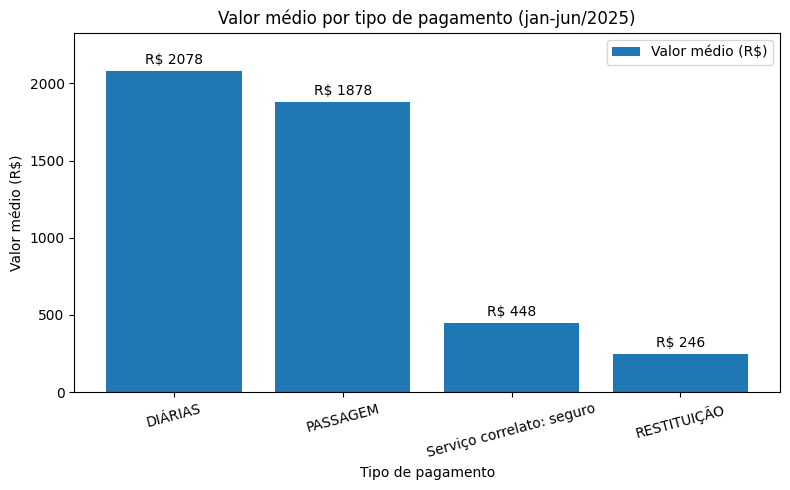

In [13]:
plt.figure(figsize=(8, 5))

barras = plt.bar(
    df["tipo_pagamento"],
    df["valor_medio"],
    label="Valor médio (R$)"
)

plt.bar_label(
    barras,
    fmt="R$ %.0f",
    padding=3
)

plt.title("Valor médio por tipo de pagamento (jan-jun/2025)")
plt.xlabel("Tipo de pagamento")
plt.ylabel("Valor médio (R$)")
plt.legend()
plt.xticks(rotation=15)

plt.ylim(0, df["valor_medio"].max() * 1.12)
plt.tight_layout()
plt.show()

In [14]:
df_ordenado = df.sort_values(
    "valor_medio",
    ascending=False
).reset_index(drop=True)

maior = df_ordenado.iloc[0]
segundo = df_ordenado.iloc[1]

percentual_acima = (
    (maior["valor_medio"] - segundo["valor_medio"])
    / segundo["valor_medio"]
) * 100

print(f"Maior categoria: {maior['tipo_pagamento']}")
print(f"Maior média: R$ {maior['valor_medio']:.2f}")
print(f"Segundo colocado: {segundo['tipo_pagamento']}")
print(f"Segunda média: R$ {segundo['valor_medio']:.2f}")
print(f"Percentual acima: {percentual_acima:.1f}%")

Maior categoria: DIÁRIAS
Maior média: R$ 2078.28
Segundo colocado: PASSAGEM
Segunda média: R$ 1878.34
Percentual acima: 10.6%


### Resposta

O tipo de pagamento com maior valor médio é **DIÁRIAS**, com **R$ 2.078,28 por
pagamento**, aproximadamente **10,6% acima de PASSAGEM**, o segundo colocado.

### Leitura

**DIÁRIAS** e **PASSAGEM** ficam muito acima dos demais, com valores médios de
**R$ 2.078,28** e **R$ 1.878,34**, respectivamente. Os outros dois tipos têm
valores bem menores: **R$ 447,51** para serviço correlato (seguro) e
**R$ 245,70** para restituição.

Isso indica que diárias e passagens são os pagamentos individuais mais altos,
enquanto seguro e restituição são valores acessórios, de menor porte.

> Observação: a média mostra o valor de um pagamento típico, não o peso de cada
> tipo no gasto total, que dependeria também de quantos pagamentos existem de
> cada tipo.

In [17]:
conexao.rollback()

sql = """
SELECT meio_transporte, COUNT(*) AS total
FROM silver_trecho
GROUP BY meio_transporte
ORDER BY total DESC;
"""
df = pd.read_sql(sql, conexao)
df

,meio_transporte,total
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481
